### Libraires

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk,string
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

### Load Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

### Dataset Strucutre Check

In [3]:
print(df.info())
print(df.head())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49577 entries, 0 to 49576
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review        49577 non-null  object
 1   sentiment     49577 non-null  object
 2   tokenization  49577 non-null  object
 3   clean_token   49577 non-null  object
 4   label         49577 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.9+ MB
None
                                              review sentiment  \
0  i looked over the other comments and was thoro...  negative   
1  i am writing this after just seeing the perfec...  positive   
2  which isn't exactly a ringing endorsement over...  negative   
3  we faw down aspect ratio sound format silent b...  negative   
4  and normally i don't like surprises watch this...  positive   

                                        tokenization  \
0  ['i', 'looked', 'over', 'the', 'other', 'comme...   
1  ['i', 'am', 'writing', 'this', 

### Check Missing Values

In [3]:
print(df.isnull().sum())

review          0
sentiment       0
tokenization    0
clean_token     0
label           0
dtype: int64


### Removing Duplicates

In [4]:
print("Original shape:", df.shape)

# Remove exact duplicates
df = df.drop_duplicates()

# Remove duplicates based on text only (same review with different labels)
df = df.drop_duplicates(subset=['review'])

print("After removing duplicates:", df.shape)

# Shuffle dataset to remove ordering bias
df = df.sample(frac=1, random_state=1).reset_index(drop=True)

# Display how many positives / negatives
print(df['sentiment'].value_counts())

Original shape: (49577, 5)
After removing duplicates: (49577, 5)
sentiment
positive    24881
negative    24696
Name: count, dtype: int64


### Clean Text

In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)     # remove HTML tags
    text = re.sub(r"[^a-zA-Z']", " ", text) # keep letters only
    text = re.sub(r"\s+", " ", text)       # remove extra spaces
    return text.strip()

df['review'] = df['review'].apply(clean_text)

### Removing Stopwords and Punctuation

In [6]:
# convert to lowercase and tokenization
def tokenize(text):
    lowercase = text.lower()
    tokens = nltk.word_tokenize(lowercase)
    return tokens

df['tokenization'] = df['review'].apply(tokenize)

#remove stopwords
stopwords_set = set(nltk.corpus.stopwords.words("english") + list(string.punctuation))

def stopwords(tokens):
    filtered_tokens = []
    for word in tokens:
        if word not in stopwords_set and word.isalpha():
            filtered_tokens.append(word)
    return filtered_tokens

df['clean_token'] = df['tokenization'].apply(stopwords)

print("\n Sample output")
print(df[['review','tokenization','clean_token']].head())

print("\n === Stopwords used ===")
print(stopwords_set)
print(f"\nTotal stopwords (including punctuation): {len(stopwords_set)}")

#save to csv
df.to_csv("IMDB Dataset.csv",index=False)


 Sample output
                                              review  \
0  i wasn't really fond of the first cube movie i...   
1  even though this film was nothing special as s...   
2  i wish i could use the time travel machine to ...   
3  nb spoiler warning such as it is first off thi...   
4  many of the reviewers have made it a point to ...   

                                        tokenization  \
0  [i, was, n't, really, fond, of, the, first, cu...   
1  [even, though, this, film, was, nothing, speci...   
2  [i, wish, i, could, use, the, time, travel, ma...   
3  [nb, spoiler, warning, such, as, it, is, first...   
4  [many, of, the, reviewers, have, made, it, a, ...   

                                         clean_token  
0  [really, fond, first, cube, movie, good, idea,...  
1  [even, though, film, nothing, special, drawn, ...  
2  [wish, could, use, time, travel, machine, jump...  
3  [nb, spoiler, warning, first, teen, slasher, f...  
4  [many, reviewers, made, point, n

### Sentiment Distribution

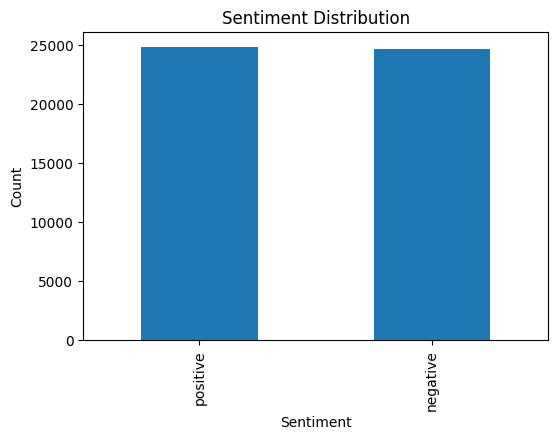

In [9]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


### Word Cloud

Positive Reviews

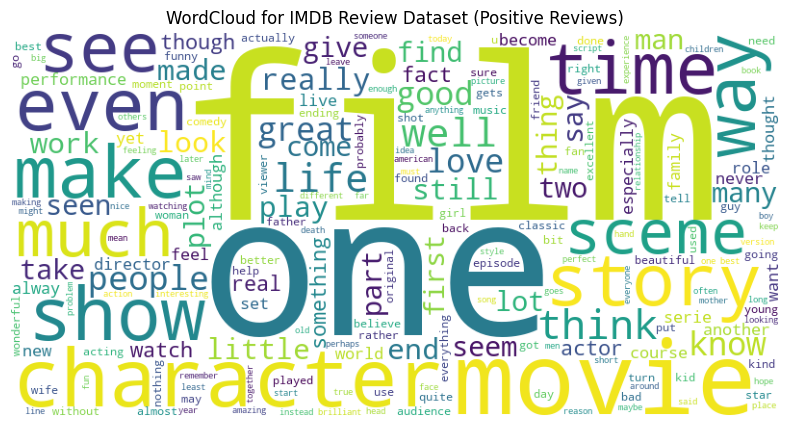

Top 10 words used for IMDB review (positive): 
[('film', 41963), ('movie', 37651), ('one', 27191), ('like', 17646), ('good', 14942), ('story', 12892), ('great', 12874), ('time', 12693), ('well', 12681), ('see', 12218)]


In [10]:
IMDB = df[df['sentiment'] == "positive"]

all_words = []
for tokens in IMDB["clean_token"]:
    for word in tokens:
        all_words.append(word)

# Generate wordcloud
wordcloud = WordCloud(
    background_color="white",
    width=800,
    height=400
).generate(" ".join(all_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud for IMDB Review Dataset (Positive Reviews)")
plt.show()

# Top 10 most common words
top_words = Counter(all_words).most_common(10)
print("Top 10 words used for IMDB review (positive): ")
print(top_words)


Negative Reviews

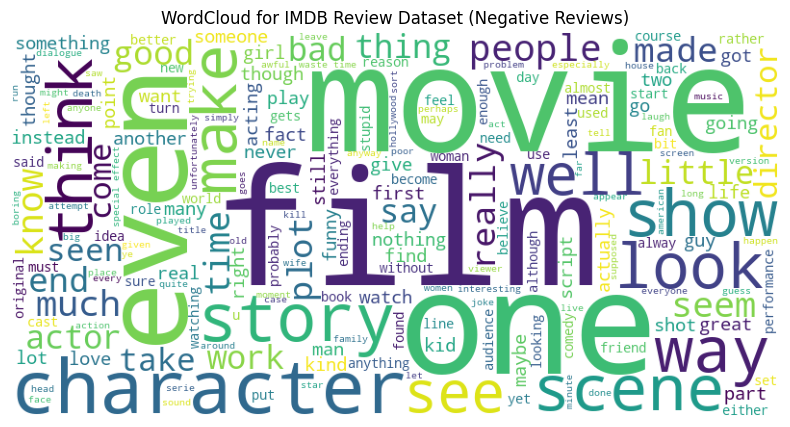

Top 10 words used for IMDB review (negative): 
[('movie', 49582), ('film', 37155), ('one', 25977), ('like', 22187), ('would', 15161), ('even', 15093), ('good', 14555), ('bad', 14513), ('really', 12214), ('time', 12193)]


In [11]:
IMDB = df[df['sentiment'] == "negative"]

all_words = []
for tokens in IMDB["clean_token"]:
    for word in tokens:
        all_words.append(word)

# Generate wordcloud
wordcloud = WordCloud(
    background_color="white",
    width=800,
    height=400
).generate(" ".join(all_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud for IMDB Review Dataset (Negative Reviews)")
plt.show()

# Top 10 most common words
top_words = Counter(all_words).most_common(10)
print("Top 10 words used for IMDB review (negative): ")
print(top_words)

### Text Length Distribution

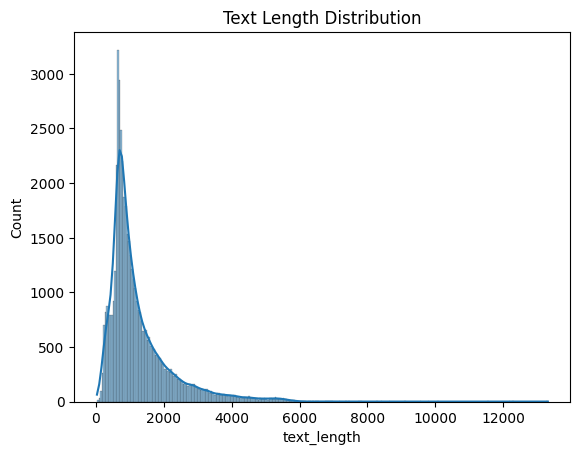

In [12]:
df['text_length'] = df['review'].apply(len)
sns.histplot(df['text_length'],kde=True)
plt.title("Text Length Distribution")
plt.show()

### TFIDF Vectorizer

In [13]:
df['clean_text'] = df['clean_token'].apply(lambda tokens: ' '.join(tokens))

TFIDF_vectorizer = TfidfVectorizer()

X = TFIDF_vectorizer.fit_transform(df['clean_text'])
y = df['sentiment'] 

print(f"TF-IDF matrix shape: {X.shape}")
print('\n', X)

TF-IDF matrix shape: (49577, 98796)

 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4798552 stored elements and shape (49577, 98796)>
  Coords	Values
  (0, 56719)	0.04315821301563856
  (0, 90464)	0.06661754037495299
  (0, 15696)	0.03651939608522296
  (0, 83420)	0.021324587555236082
  (0, 35784)	0.03354254149575009
  (0, 50362)	0.051171229948305315
  (0, 9337)	0.4963411092269777
  (0, 35275)	0.09316004046335657
  (0, 58681)	0.13382349310461183
  (0, 2028)	0.5254748869856902
  (0, 51455)	0.026272360825137623
  (0, 95057)	0.029863342920398057
  (0, 34886)	0.04471454187397639
  (0, 53525)	0.09538197318233009
  (0, 11327)	0.07017723759216479
  (0, 62853)	0.4044213947750064
  (0, 97158)	0.039592515807242136
  (0, 45220)	0.062278397858436696
  (0, 50379)	0.048498845000721595
  (0, 38171)	0.05691558522278115
  (0, 4263)	0.09038978677164561
  (0, 38180)	0.13592761501524916
  (0, 76920)	0.06214228103498034
  (0, 39001)	0.29004727343180997
  (0, 464)	0.05239717828407864
  :	:
  (4

### Encode Labels

Change the sentiment from 'positive','negative' into 1 and 0

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print(le.classes_)

['negative' 'positive']


### Padding, Split Train and Test Data

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Use the cleaned tokens, join them into strings first
texts = df['clean_token'].apply(lambda x: ' '.join(x)).values

# Initialize the tokenizer
vocab_size = 15000  # choose as needed
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(texts)

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(texts)

# Pad/truncate sequences
max_len = 250  # or any length you prefer
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, df['label'], test_size=0.3, random_state=1
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (34703, 250)
X_test shape: (14874, 250)


### Model Building

LSTM

In [13]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential()
model_lstm.add(Embedding(vocab_size, embedding_dim))
model_lstm.add(LSTM(128, return_sequences=False))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=4,
    batch_size=32
)

# Predict & evaluate
y_pred_lstm = (model_lstm.predict(X_test) > 0.5).astype("int32")
print("\n=== LSTM Classification Report ===")
print(classification_report(y_test, y_pred_lstm, digits=3))

lstm_matrix = confusion_matrix(y_test, y_pred_lstm)
print("\nConfusion Matrix:\n", lstm_matrix)


Epoch 1/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 182s 205ms/step - accuracy: 0.5006 - loss: 0.6937 - val_accuracy: 0.5113 - val_loss: 0.6928
Epoch 2/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 105s 121ms/step - accuracy: 0.5133 - loss: 0.6886 - val_accuracy: 0.4929 - val_loss: 0.6991
Epoch 3/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 106s 122ms/step - accuracy: 0.5377 - loss: 0.6592 - val_accuracy: 0.4950 - val_loss: 0.6940
Epoch 4/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 109s 125ms/step - accuracy: 0.5598 - loss: 0.6504 - val_accuracy: 0.5793 - val_loss: 0.7129
465/465 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step

=== LSTM Classification Report ===
              precision    recall  f1-score   support

           0      0.678     0.276     0.393      7446
           1      0.545     0.868     0.670      7428

    accuracy                          0.572     14874
   macro avg      0.611     0.572     0.531     14874
weighted avg      0.611     0.572     0.531     14874


Confusion Matrix:
 [[2057 5389]
 [ 977 6451]]


 CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
embedding_dim = 100
model_cnn = Sequential()
model_cnn.add(Embedding(vocab_size, embedding_dim))
model_cnn.add(Conv1D(128, kernel_size=5, activation='relu'))
model_cnn.add(GlobalMaxPooling1D())
model_cnn.add(Dropout(0.3))
model_cnn.add(Dense(1, activation='sigmoid'))
model_cnn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=4,
    batch_size=32
)
# Predict & evaluate
y_pred_cnn = (model_cnn.predict(X_test) > 0.5).astype("int32")
print("\n=== CNN Classification Report ===")
print(classification_report(y_test, y_pred_cnn, digits=3))
cnn_matrix = confusion_matrix(y_test, y_pred_cnn)
print("\nConfusion Matrix:\n", cnn_matrix)


Epoch 1/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8097 - loss: 0.4099 - val_accuracy: 0.8626 - val_loss: 0.3173
Epoch 2/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.9112 - loss: 0.2264 - val_accuracy: 0.8705 - val_loss: 0.3092
Epoch 3/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.9623 - loss: 0.1114 - val_accuracy: 0.8657 - val_loss: 0.3586
Epoch 4/4
868/868 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9867 - loss: 0.0452 - val_accuracy: 0.8585 - val_loss: 0.4479
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

=== CNN Classification Report ===
              precision    recall  f1-score   support

           0      0.864     0.865     0.865      7446
           1      0.865     0.863     0.864      7428

    accuracy                          0.864     14874
   macro avg      0.864     0.864     0.864     14874
weighted avg      0.864     0.864     0.864     14874


Confusion Matrix:
 [[6444 1002]
 [1015 6413]]


### Hyperparameters (Random Search)

LSTM

In [9]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.optimizers import Adam

vocab_size = 15000 
embedding_dim = 100
max_seq_length = 250 

def create_lstm_model(units=128, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()
    model.add(Embedding(
        input_dim=15000, 
        output_dim=100, 
        input_length=250  
    ))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.build(input_shape=(None, max_seq_length))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model
keras_clf = KerasClassifier(
    model=create_lstm_model, 
    epochs=8,
    batch_size=32,
    verbose=0 
)
param_dist = {
    'model__units': [64, 128, 256],
    'model__dropout_rate': [0.2, 0.3, 0.4, 0.5],
    'model__learning_rate': [0.01, 0.005, 0.001, 0.0005],
    'epochs': [5, 8, 10, 15], 
    'batch_size': [16, 32, 64]
}
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=5, 
    scoring='accuracy',
    cv=2, 
    verbose=2,
    n_jobs=-1 # Use all available CPU cores
)
print("\n--- Starting Randomized Search Cross-Validation ---")
random_search_result = random_search.fit(X_train, y_train) 
print("--- Randomized Search Complete ---")
best_params = random_search_result.best_params_
best_score = random_search_result.best_score_
best_model = random_search_result.best_estimator_
print(f"\n✅ Best Cross-Validation Accuracy: {best_score*100:.3f}%")
print(f"✅ Best Parameters Found: {best_params}")
print("\n--- Final Evaluation on Test Set ---")
y_pred_best = (best_model.predict(X_test) > 0.5).astype("int32")
print("\n=== Best Model Classification Report ===")
print(classification_report(y_test, y_pred_best, digits=3))
lstm_matrix = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:\n", lstm_matrix)


--- Starting Randomized Search Cross-Validation ---
Fitting 2 folds for each of 5 candidates, totalling 10 fits


c:\Users\HP PAVILION 15\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


--- Randomized Search Complete ---

✅ Best Cross-Validation Accuracy: 84.615%
✅ Best Parameters Found: {'model__units': 128, 'model__learning_rate': 0.005, 'model__dropout_rate': 0.3, 'epochs': 8, 'batch_size': 16}

--- Final Evaluation on Test Set ---

=== Best Model Classification Report ===
              precision    recall  f1-score   support

           0      0.877     0.862     0.869      7446
           1      0.864     0.879     0.871      7428

    accuracy                          0.870     14874
   macro avg      0.870     0.870     0.870     14874
weighted avg      0.870     0.870     0.870     14874


Confusion Matrix:
 [[6417 1029]
 [ 899 6529]]


CNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from keras.optimizers import Adam

vocab_size = 15000 
embedding_dim = 100 
max_seq_length = 250 

def create_cnn_model(filters=128, kernel_size=5, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()
    model.add(Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim, 
        input_length=max_seq_length
    ))
    model.add(Conv1D(filters, kernel_size=kernel_size, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.build(input_shape=(None, max_seq_length))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model
keras_clf = KerasClassifier(
    model=create_cnn_model, 
    epochs=8,
    batch_size=32,
    verbose=0 
)
param_dist = {
    'model__filters': [64, 128, 256],          # Number of convolutional filters
    'model__kernel_size': [3, 5, 7],           # Size of the convolution window
    'model__dropout_rate': [0.3, 0.4, 0.5],    # Dropout rate after pooling
    'model__learning_rate': [0.001, 0.0005, 0.0001],
    'epochs': [10, 15, 20],  
    'batch_size': [32, 64, 128]
}
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=5, 
    scoring='accuracy',
    cv=2, 
    verbose=2, 
    n_jobs=-1 
)
print("\n--- Starting Randomized Search Cross-Validation for CNN (15 iterations, 3 folds) ---")
random_search_result = random_search.fit(X_train, y_train) 
print("--- Randomized Search Complete ---")
best_params = random_search_result.best_params_
best_score = random_search_result.best_score_
best_model = random_search_result.best_estimator_
print(f"\n✅ Best Cross-Validation Accuracy: {best_score*100:.3f}%")
print(f"✅ Best Parameters Found: {best_params}")
print("\n--- Final Evaluation on Test Set ---")
y_pred_best = (best_model.predict(X_test) > 0.5).astype("int32")
print("\n=== Best CNN Model Classification Report ===")
print(classification_report(y_test, y_pred_best, digits=3))
cnn_matrix = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:\n", cnn_matrix)


--- Starting Randomized Search Cross-Validation for CNN (15 iterations, 3 folds) ---
Fitting 2 folds for each of 5 candidates, totalling 10 fits


c:\Users\HP PAVILION 15\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


--- Randomized Search Complete ---

✅ Best Cross-Validation Accuracy: 85.609%
✅ Best Parameters Found: {'model__learning_rate': 0.0001, 'model__kernel_size': 7, 'model__filters': 64, 'model__dropout_rate': 0.4, 'epochs': 10, 'batch_size': 32}

--- Final Evaluation on Test Set ---

=== Best CNN Model Classification Report ===
              precision    recall  f1-score   support

           0      0.869     0.851     0.860      7446
           1      0.854     0.871     0.862      7428

    accuracy                          0.861     14874
   macro avg      0.861     0.861     0.861     14874
weighted avg      0.861     0.861     0.861     14874


Confusion Matrix:
 [[6340 1106]
 [ 959 6469]]
